In [ ]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual para los gráficos de Seaborn
sns.set_theme(style="whitegrid")

# Carga de los datasets usando RUTAS ABSOLUTAS
try:
    df_calls = pd.read_csv(r'C:\Users\kevin\Proyecto_Final_TT\telecom_dataset_new.csv')
    df_clients = pd.read_csv(r'C:\Users\kevin\Proyecto_Final_TT\telecom_clients.csv')
    print("✅ ¡Datasets cargados con éxito!")
except FileNotFoundError:
    print("❌ Error: Sigue sin encontrar los archivos.")

✅ ¡Datasets cargados con éxito!


In [ ]:
# Inspección general de la tabla de llamadas
print("--- INFORMACIÓN GENERAL: df_calls ---")
df_calls.info()

print("\n--- CONTEO DE VALORES NULOS: df_calls ---")
display(df_calls.isna().sum())

print("\n" + "="*50 + "\n")

# Inspección general de la tabla de clientes
print("--- INFORMACIÓN GENERAL: df_clients ---")
df_clients.info()

--- INFORMACIÓN GENERAL: df_calls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

--- CONTEO DE VALORES NULOS: df_calls ---


user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64



--- INFORMACIÓN GENERAL: df_clients ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [ ]:
# 1. Transformar texto a Fechas (Datetime)
df_calls['date'] = pd.to_datetime(df_calls['date'], format='ISO8601')
# Extraemos solo la fecha (sin la hora) para facilitar el análisis diario
df_calls['date'] = df_calls['date'].dt.date 
df_calls['date'] = pd.to_datetime(df_calls['date'])

df_clients['date_start'] = pd.to_datetime(df_clients['date_start'])

# 2. Limpieza de Nulos (Decisión de Negocio)
# Eliminamos filas sin operador porque no podemos evaluarlos
df_calls.dropna(subset=['operator_id'], inplace=True)
# Eliminamos el 0.2% de llamadas sin dirección interna/externa
df_calls.dropna(subset=['internal'], inplace=True)

# 3. Formateo de IDs (Limpieza estética)
# Como los IDs de operador ahora no tienen nulos, los pasamos a números enteros (sin decimales)
df_calls['operator_id'] = df_calls['operator_id'].astype('int')

# 4. Unión de Datos (MERGE)
# Traemos el plan tarifario de cada cliente a nuestra tabla de llamadas
df_final = df_calls.merge(df_clients, on='user_id', how='left')

# Verificamos cómo quedó nuestra obra de arte
print("✅ Limpieza y Unión completadas con éxito.")
print(f"Total de registros listos para analizar: {len(df_final)}")
display(df_final.head())

✅ Limpieza y Unión completadas con éxito.
Total de registros listos para analizar: 45670


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
0,166377,2019-08-05,out,True,880022,True,3,0,5,B,2019-08-01
1,166377,2019-08-05,out,True,880020,True,1,0,1,B,2019-08-01
2,166377,2019-08-05,out,True,880020,False,1,10,18,B,2019-08-01
3,166377,2019-08-05,out,False,880022,True,3,0,25,B,2019-08-01
4,166377,2019-08-05,out,False,880020,False,2,3,29,B,2019-08-01


## Fase 2: Ingeniería de Características y Análisis Exploratorio (EDA)

### 2.1 Ingeniería de Características: Calculando el Tiempo de Espera
Para cumplir con el objetivo del negocio de identificar operadores ineficaces, necesitamos medir el "tiempo de espera prolongado". Nuestro proveedor de datos no nos entregó esta métrica directamente, pero nos dio la duración real de la llamada (`call_duration`) y el tiempo total de la conexión (`total_call_duration`). 

Como analistas, crearemos una nueva característica (`wait_time`) restando la duración real del tiempo total. Esta métrica será uno de nuestros pilares para evaluar el rendimiento del personal.

In [ ]:
# 1. Calculamos el tiempo de espera en una nueva columna
df_final['wait_time'] = df_final['total_call_duration'] - df_final['call_duration']

# 2. Control de calidad (Data Quality)
# En la vida real, los sistemas de telefonía fallan y pueden registrar tiempos negativos por error.
# Vamos a revisar si tenemos ese problema.
errores_sistema = df_final[df_final['wait_time'] < 0]
print(f"Llamadas con tiempo de espera negativo (errores de sistema): {len(errores_sistema)}")

# 3. Limpiamos esos errores lógicos si es que existen
df_final = df_final[df_final['wait_time'] >= 0]

print("✅ Métrica 'wait_time' creada y validada exitosamente.")
display(df_final[['call_duration', 'total_call_duration', 'wait_time']].head())

Llamadas con tiempo de espera negativo (errores de sistema): 0
✅ Métrica 'wait_time' creada y validada exitosamente.


,call_duration,total_call_duration,wait_time
0,0,5,5
1,0,1,1
2,10,18,8
3,0,25,25
4,3,29,26


### 2.2 Análisis Exploratorio de Datos (EDA): Comprendiendo la "Normalidad"
En el análisis de datos, no podemos definir qué es un comportamiento "anormal" (o ineficaz) sin antes entender cómo se ve la "normalidad". 

A continuación, generaremos estadísticas descriptivas para nuestras variables numéricas clave y visualizaremos la distribución del tiempo de espera. Esto nos ayudará a detectar valores atípicos (outliers) extremos que podrían estar distorsionando nuestros promedios globales.

--- ESTADÍSTICAS DESCRIPTIVAS GLOBALES ---


,calls_count,call_duration,wait_time
count,45670.000000,45670.000000,45670.000000
mean,16.925203,1010.934399,312.762601
std,59.081220,4017.101865,1174.908171
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,19.000000
50%,4.000000,107.000000,60.000000
75%,14.000000,774.000000,221.000000
max,4817.000000,144395.000000,46474.000000


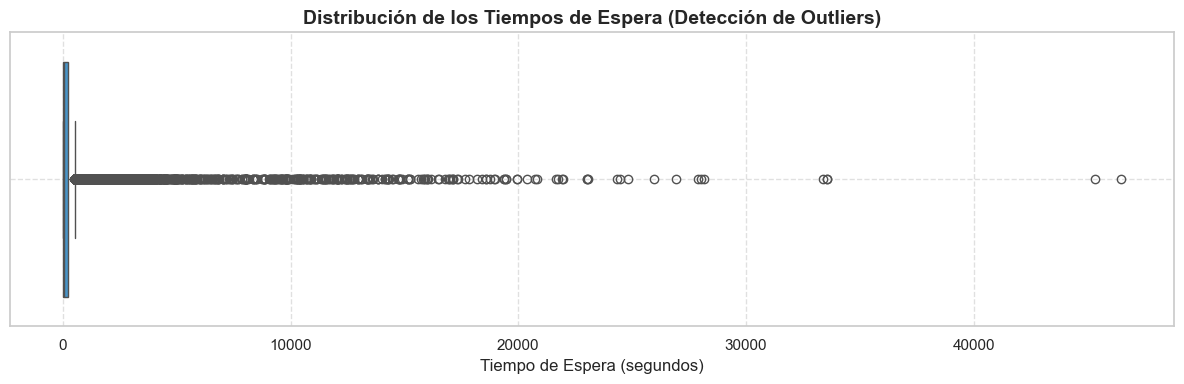

In [ ]:
# 1. Estadísticas descriptivas de las métricas clave
print("--- ESTADÍSTICAS DESCRIPTIVAS GLOBALES ---")
display(df_final[['calls_count', 'call_duration', 'wait_time']].describe())

# 2. Visualización para detectar Outliers (Valores Atípicos)
plt.figure(figsize=(12, 4))

# Usamos un Boxplot (diagrama de caja) porque es la mejor herramienta visual para detectar outliers
sns.boxplot(x=df_final['wait_time'], color='#3498db')

plt.title('Distribución de los Tiempos de Espera (Detección de Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo de Espera (segundos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 2.2 Tratamiento de Anomalías y Valores Atípicos
El análisis descriptivo revela una discrepancia masiva entre la mediana y el promedio debido a valores atípicos extremos. Por ejemplo:
* **Tiempo de espera:** La mediana es de 60 segundos (1 minuto), pero existen registros anómalos de hasta 46,474 segundos (casi 13 horas).
* **Duración de llamada:** La mediana es de 107 segundos (1.7 minutos), pero existen registros de hasta 144,395 segundos (40 horas).

Estos valores máximos representan fallas tecnológicas (líneas abandonadas o errores del servidor), no el rendimiento humano. Para evaluar la ineficacia de los operadores de manera justa, aplicaremos un filtro estadístico (Percentil 99) para eliminar este 1% de registros corruptos y aislar la operación real.

In [ ]:
# Definimos los límites (Percentil 99) para aislar datos atípicos
limite_llamadas = df_final['calls_count'].quantile(0.99)
limite_duracion = df_final['call_duration'].quantile(0.99)
limite_espera = df_final['wait_time'].quantile(0.99)

# Filtramos el dataset para quedarnos solo con el comportamiento operativo "normal"
df_clean = df_final[
    (df_final['calls_count'] <= limite_llamadas) &
    (df_final['call_duration'] <= limite_duracion) &
    (df_final['wait_time'] <= limite_espera)
].copy()

print("--- REPORTE DE LIMPIEZA DE ANOMALÍAS ---")
print(f"Registros originales: {len(df_final)}")
print(f"Registros después de la limpieza: {len(df_clean)}")
print(f"Total de registros atípicos eliminados: {len(df_final) - len(df_clean)}")
print("\n✅ Dataset optimizado y listo para identificar operadores ineficaces.")

--- REPORTE DE LIMPIEZA DE ANOMALÍAS ---
Registros originales: 45670
Registros después de la limpieza: 44908
Total de registros atípicos eliminados: 762

✅ Dataset optimizado y listo para identificar operadores ineficaces.


## Fase 3: Identificación de Operadores Ineficaces

Para evaluar el rendimiento del personal basándonos en las reglas de negocio de *CallMeMaybe*, crearemos un perfil de rendimiento por cada operador (`operator_id`). Calcularemos tres métricas clave usando exclusivamente los datos limpios:

1. **Llamadas entrantes perdidas:** Suma total de llamadas entrantes que no fueron atendidas.
2. **Tiempo de espera promedio:** El tiempo medio que un operador hace esperar a los clientes en llamadas entrantes.
3. **Volumen de llamadas salientes:** Suma total de llamadas salientes realizadas.

Agruparemos esta información en una única tabla maestra para poder establecer los umbrales estadísticos de ineficacia.

### 3.1 Aplicación de las Reglas de Ineficacia
Con el perfil de cada operador establecido, definiremos los umbrales matemáticos para las reglas del negocio basándonos en la distribución real de los datos:

* **Regla A (Llamadas perdidas):** El 75% de los operadores pierde 0 llamadas. Catalogaremos como ineficaz a quien pierda más de 10 llamadas entrantes (superando ampliamente el promedio y la desviación estándar).
* **Regla B (Tiempo de espera):** El 75% de los operadores tiene un tiempo de espera promedio inferior a 43 segundos. Catalogaremos como ineficaz a quien tenga un promedio superior a 60 segundos (1 minuto).
* **Regla C (Llamadas salientes):** Si un operador tiene actividad saliente (más de 0 llamadas), pero realiza menos de 36 llamadas en total (la mediana), se considerará ineficaz en su rol de salida.

Crearemos una función para etiquetar a los operadores que cumplan alguna de estas condiciones.

In [ ]:
# 1. Separamos las llamadas por dirección para aplicar las reglas correctamente
entrantes = df_clean[df_clean['direction'] == 'in']
salientes = df_clean[df_clean['direction'] == 'out']

# Regla A: Total de llamadas entrantes perdidas por operador
perdidas_in = entrantes[entrantes['is_missed_call'] == True].groupby('operator_id')['calls_count'].sum().reset_index(name='missed_incoming')

# Regla B: Tiempo de espera promedio por operador (solo entrantes)
espera_in = entrantes.groupby('operator_id')['wait_time'].mean().reset_index(name='avg_wait_time')

# Regla C: Total de llamadas salientes por operador
volumen_out = salientes.groupby('operator_id')['calls_count'].sum().reset_index(name='total_outgoing')

# 2. Unimos todo en un "Boletín de Calificaciones" por operador
# Usamos 'outer' para no perder a los operadores que, por ejemplo, solo hacen llamadas entrantes y cero salientes
operadores_stats = perdidas_in.merge(espera_in, on='operator_id', how='outer')
operadores_stats = operadores_stats.merge(volumen_out, on='operator_id', how='outer')

# Llenamos con 0 los nulos (ej. un operador que tuvo 0 llamadas perdidas, o 0 llamadas salientes)
operadores_stats.fillna(0, inplace=True)

print("--- BOLETÍN DE CALIFICACIONES DE LOS OPERADORES ---")
print(f"Total de operadores únicos a evaluar: {len(operadores_stats)}")
display(operadores_stats.describe())
display(operadores_stats.head())

--- BOLETÍN DE CALIFICACIONES DE LOS OPERADORES ---
Total de operadores únicos a evaluar: 1092


,operator_id,missed_incoming,avg_wait_time,total_outgoing
count,1092.000000,1092.000000,1092.000000,1092.000000
mean,925517.543956,0.924908,39.346367,403.025641
std,22854.532209,3.543089,80.414546,786.495227
min,879896.000000,0.000000,0.000000,0.000000
25%,906393.500000,0.000000,0.000000,2.000000
50%,925105.000000,0.000000,18.891667,36.500000
75%,944211.500000,0.000000,43.000000,377.000000
max,973286.000000,55.000000,1039.540541,7856.000000


,operator_id,missed_incoming,avg_wait_time,total_outgoing
0,879896,0.0,26.913043,1071.0
1,879898,0.0,28.539683,7856.0
2,880020,0.0,7.250000,46.0
3,880022,0.0,14.000000,211.0
4,880026,0.0,7.894737,2414.0


--- RESULTADOS DE LA AUDITORÍA DE PERSONAL ---


etiqueta
Eficaz                        617
Ineficaz (Pocas Salientes)    296
Ineficaz (Larga Espera)       154
Ineficaz (Muchas Pérdidas)     25
Name: count, dtype: int64

C:\Users\kevin\AppData\Local\Temp\ipykernel_24184\3831165743.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=operadores_stats, y='etiqueta', order=resumen_ineficacia.index, palette='Set2')


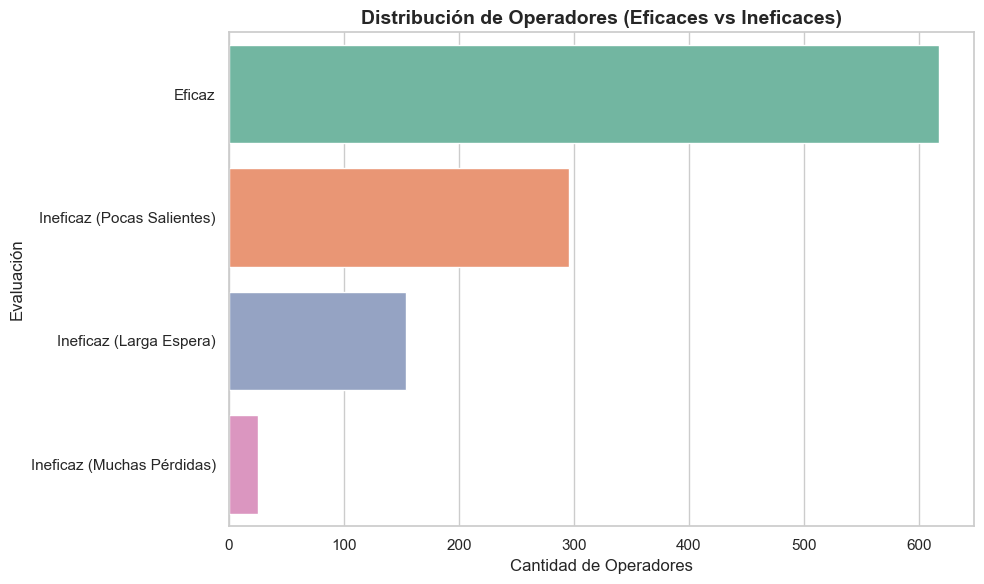

In [ ]:
# Definimos los umbrales estáticos basados en tu reporte .describe()
UMBRAL_PERDIDAS = 10
UMBRAL_ESPERA = 60
UMBRAL_SALIENTES = 36 # La mediana

def clasificar_operador(row):
    # Regla A: Gran cantidad de llamadas perdidas
    if row['missed_incoming'] > UMBRAL_PERDIDAS:
        return 'Ineficaz (Muchas Pérdidas)'
    
    # Regla B: Tiempo de espera prolongado
    elif row['avg_wait_time'] > UMBRAL_ESPERA:
        return 'Ineficaz (Larga Espera)'
    
    # Regla C: Muy pocas llamadas salientes (Solo si hacen llamadas salientes)
    elif (row['total_outgoing'] > 0) and (row['total_outgoing'] < UMBRAL_SALIENTES):
        return 'Ineficaz (Pocas Salientes)'
    
    # Si no rompe ninguna regla, es un operador eficaz
    else:
        return 'Eficaz'

# Aplicamos la función a nuestro boletín de calificaciones
operadores_stats['etiqueta'] = operadores_stats.apply(clasificar_operador, axis=1)

# Vemos el resumen de la auditoría
resumen_ineficacia = operadores_stats['etiqueta'].value_counts()
print("--- RESULTADOS DE LA AUDITORÍA DE PERSONAL ---")
display(resumen_ineficacia)

# Gráfico para la presentación a los directivos
plt.figure(figsize=(10, 6))
sns.countplot(data=operadores_stats, y='etiqueta', order=resumen_ineficacia.index, palette='Set2')
plt.title('Distribución de Operadores (Eficaces vs Ineficaces)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Operadores')
plt.ylabel('Evaluación')
plt.tight_layout()
plt.show()

<Axes: xlabel='count', ylabel='etiqueta'>

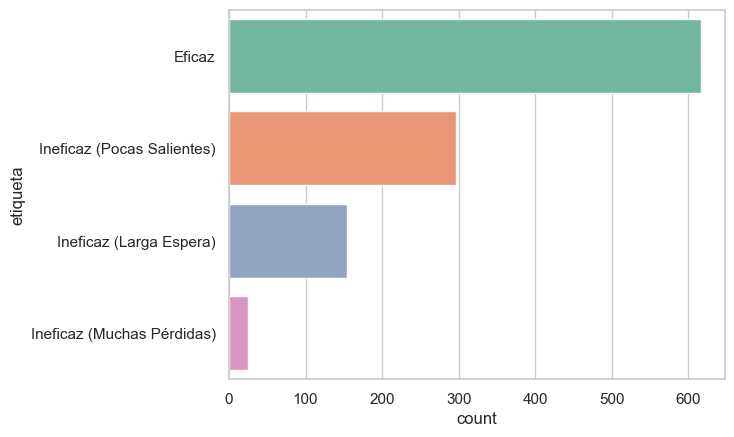

In [ ]:
sns.countplot(data=operadores_stats, y='etiqueta', order=resumen_ineficacia.index, hue='etiqueta', palette='Set2', legend=False)

## Fase 4: Pruebas de Hipótesis Estadísticas

Para aportar mayor valor al negocio, comprobaremos si existen diferencias estadísticamente significativas en el comportamiento operativo. Utilizaremos la prueba T de Student para muestras independientes (Prueba de Welch), estableciendo un nivel de significación estadística (alfa) del 5% (0.05).

**Hipótesis 1: Impacto del tipo de llamada en el tiempo de espera**
* **H0 (Nula):** El tiempo de espera promedio es igual para las llamadas internas que para las externas.
* **H1 (Alternativa):** El tiempo de espera promedio es diferente entre llamadas internas y externas.

**Hipótesis 2: Comportamiento de los clientes según su plan tarifario**
* **H0 (Nula):** La duración promedio de las llamadas es igual para los clientes del Plan A y del Plan B.
* **H1 (Alternativa):** La duración promedio de las llamadas es diferente entre los clientes del Plan A y del Plan B.

In [ ]:
# Nivel de significación (alfa)
alpha = 0.05

print("="*60)
print("HIPÓTESIS 1: Tiempo de espera (Internas vs Externas)")
print("="*60)

# Filtramos los datos (usando nuestra base limpia)
espera_internas = df_clean[df_clean['internal'] == True]['wait_time']
espera_externas = df_clean[df_clean['internal'] == False]['wait_time']

# Realizamos la prueba T de Welch (equal_var=False porque las varianzas pueden ser distintas)
results_h1 = stats.ttest_ind(espera_internas, espera_externas, equal_var=False)

print(f"Valor p (p-value): {results_h1.pvalue}")
if results_h1.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa en el tiempo de espera entre llamadas internas y externas.")
else:
    print("No podemos rechazar la hipótesis nula: No hay diferencia significativa.")


print("\n" + "="*60)
print("HIPÓTESIS 2: Duración de llamadas (Plan A vs Plan B)")
print("="*60)

# Filtramos los datos por plan tarifario
duracion_plan_a = df_clean[df_clean['tariff_plan'] == 'A']['call_duration']
duracion_plan_b = df_clean[df_clean['tariff_plan'] == 'B']['call_duration']

# Realizamos la prueba T de Welch
results_h2 = stats.ttest_ind(duracion_plan_a, duracion_plan_b, equal_var=False)

print(f"Valor p (p-value): {results_h2.pvalue}")
if results_h2.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa en la duración de las llamadas entre el Plan A y el Plan B.")
else:
    print("No podemos rechazar la hipótesis nula: No hay diferencia significativa.")

HIPÓTESIS 1: Tiempo de espera (Internas vs Externas)
Valor p (p-value): 0.0
Rechazamos la hipótesis nula: Hay una diferencia significativa en el tiempo de espera entre llamadas internas y externas.

HIPÓTESIS 2: Duración de llamadas (Plan A vs Plan B)
Valor p (p-value): 1.0505354320848839e-14
Rechazamos la hipótesis nula: Hay una diferencia significativa en la duración de las llamadas entre el Plan A y el Plan B.


In [ ]:
# 1. Extraemos solo las etiquetas de nuestra auditoría
etiquetas_operadores = operadores_stats[['operator_id', 'etiqueta']]

# 2. Unimos estas etiquetas a nuestra base de llamadas completamente limpia
df_dashboard = df_clean.merge(etiquetas_operadores, on='operator_id', how='left')

# 3. Exportamos el resultado final a un archivo CSV en tu misma carpeta local
ruta_exportacion = r'C:\Users\kevin\Proyecto_Final_TT\dataset_tableau_callmemaybe.csv'
df_dashboard.to_csv(ruta_exportacion, index=False)

print("="*60)
print(f"✅ ¡ÉXITO TOTAL! Datos listos")
print(f"Archivo guardado en: {ruta_exportacion}")
print("="*60)

✅ ¡ÉXITO TOTAL! Datos listos
Archivo guardado en: C:\Users\kevin\Proyecto_Final_TT\dataset_tableau_callmemaybe.csv
